# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 10     |  |
| :-------------|:-------------|
| Siemen Spek| 6579531 |
| Tom Jongbloed| 6581048 |
| Batu Sönmez| 6175163 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Siemen Spek', 'Tom Jongbloed','Batu Sönmez']

## Opdracht 1: Planning.

| Planning Groep: 10     |Tijdstip / Tijdspanne  |
|---|---|
| pull request gemaakt | 11.30 |
| kalibratie arduinometing | 12.15 |
| testen meetopstelling | 12.45 |
| pauze 1 | 12.45 - 13.45 |
| pauze 2| 16.00 - 16.30 |
| eerste algoritme ideeen| 14.00 |
| iteratie 0 | 14.30 |
| iteratie 1 | 15.00 |
| opdracht af | 17.45 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [10]
<img src="kalibratie_opstelling.jpeg" width="400">

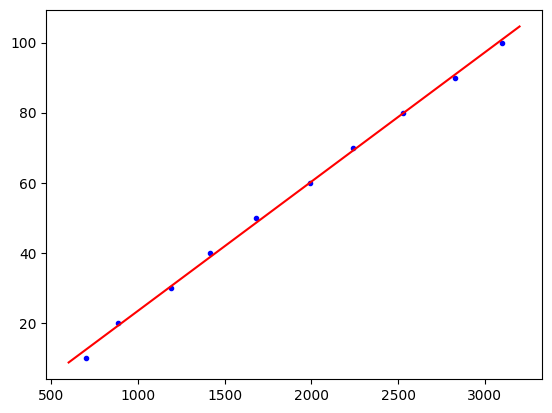

 a = 0.03688
 b = -13.43215


In [3]:
# verwerk hier jullie kalibratiemetingen
kalibratie_bits = np.array([700,886,1189,1413,1680,1992,2242,2530,2825,3100 ])
kalibratie_afstand = np.array([10,20,30,40,50,60,70,80,90,100])


def function(x,a,b):
    return a*x+b

values, covariance = curve_fit(function,kalibratie_bits,kalibratie_afstand)

x_fit = np.linspace(600,3200,300)

plt.figure()
plt.plot(kalibratie_bits,kalibratie_afstand,'b.')
plt.plot(x_fit, function(x_fit,*values),'r-')
plt.show()
print(f' a = {values[0]:.5f}')
print(f' b = {values[1]:.5f}')

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  45.65
1   0  30   0  20  45.02
2  40   0  30   0  40.00
3  30   0  20   0  40.74


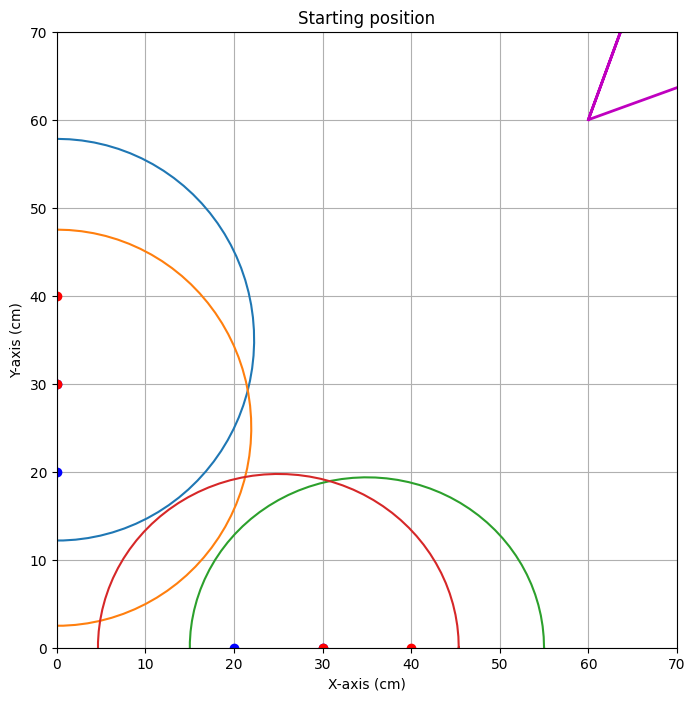


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=99.102


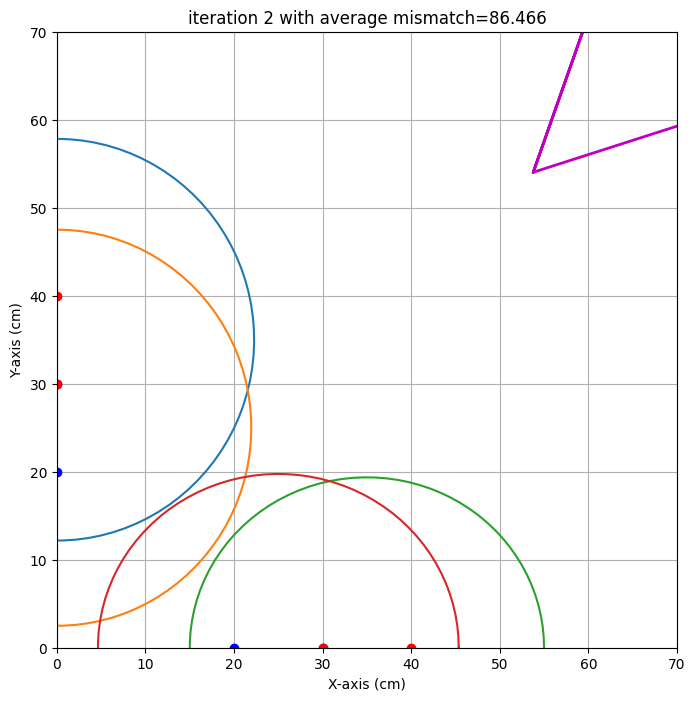

end iteration 2 with average mismatch=86.466


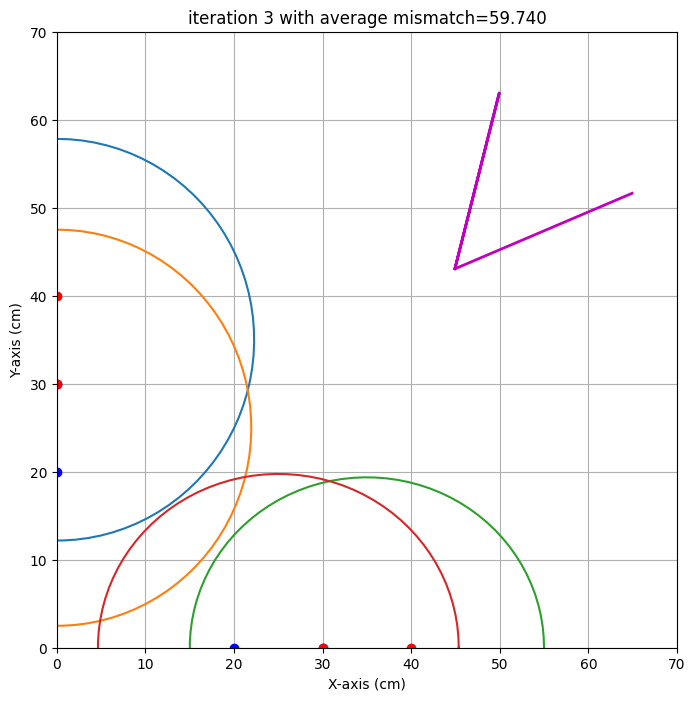

end iteration 3 with average mismatch=59.740


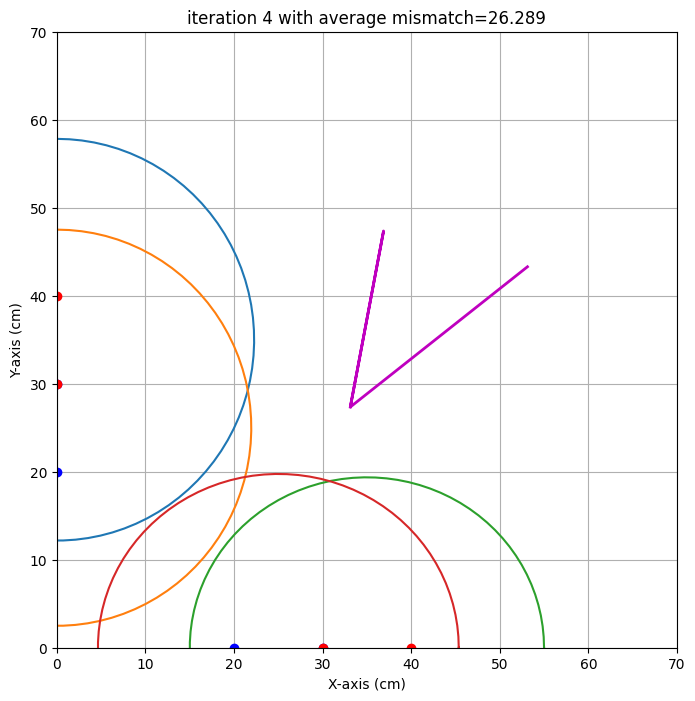

end iteration 4 with average mismatch=26.289


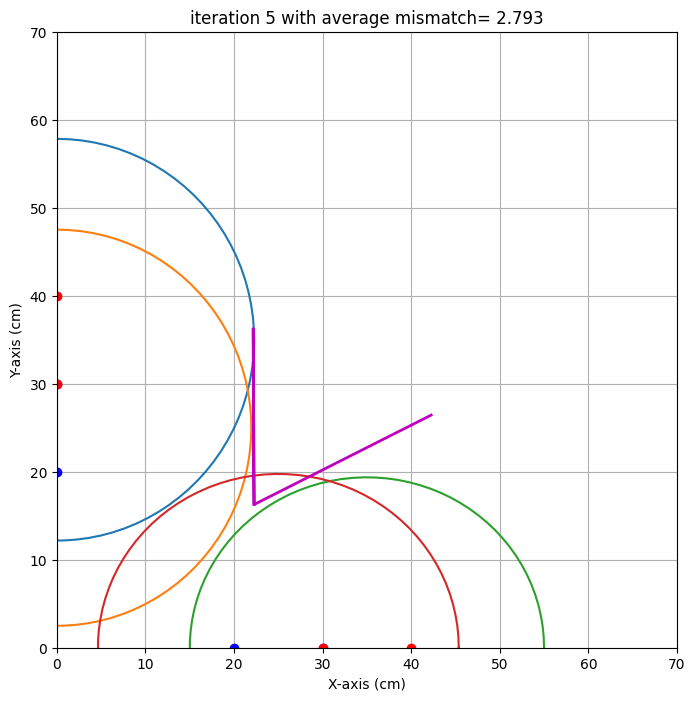

end iteration 5 with average mismatch= 2.793


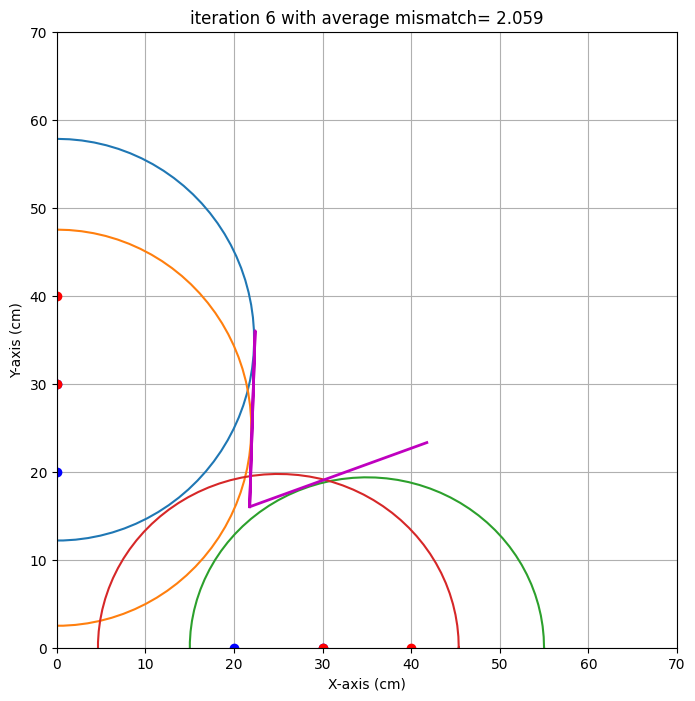

end iteration 6 with average mismatch= 2.059
end iteration 7 with average mismatch= 1.911
end iteration 8 with average mismatch= 1.864
end iteration 9 with average mismatch= 1.844
end iteration 10 with average mismatch= 1.842
end iteration 11 with average mismatch= 1.801
end iteration 12 with average mismatch= 1.714


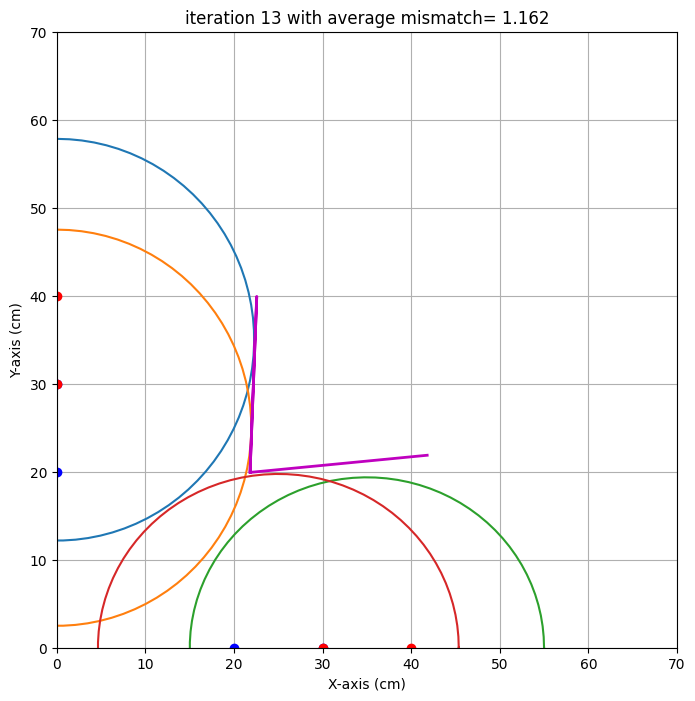

end iteration 13 with average mismatch= 1.162


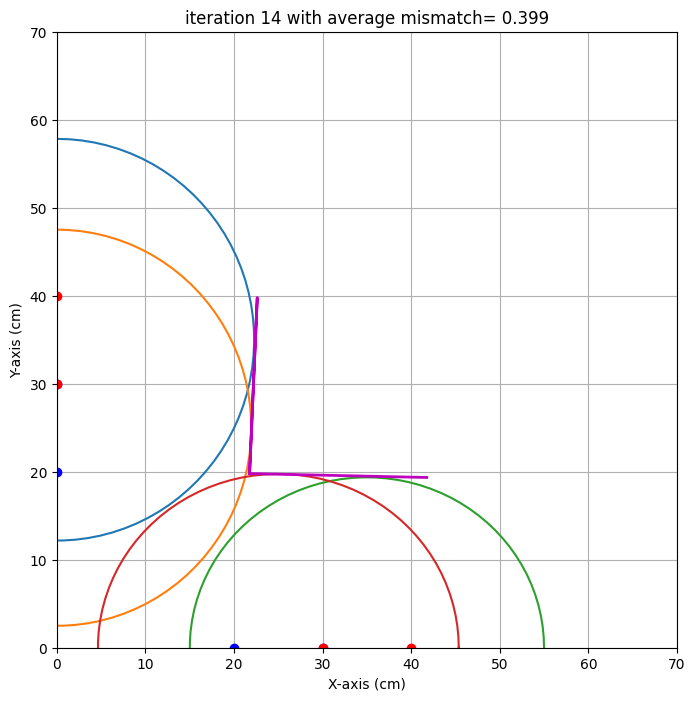

end iteration 14 with average mismatch= 0.399


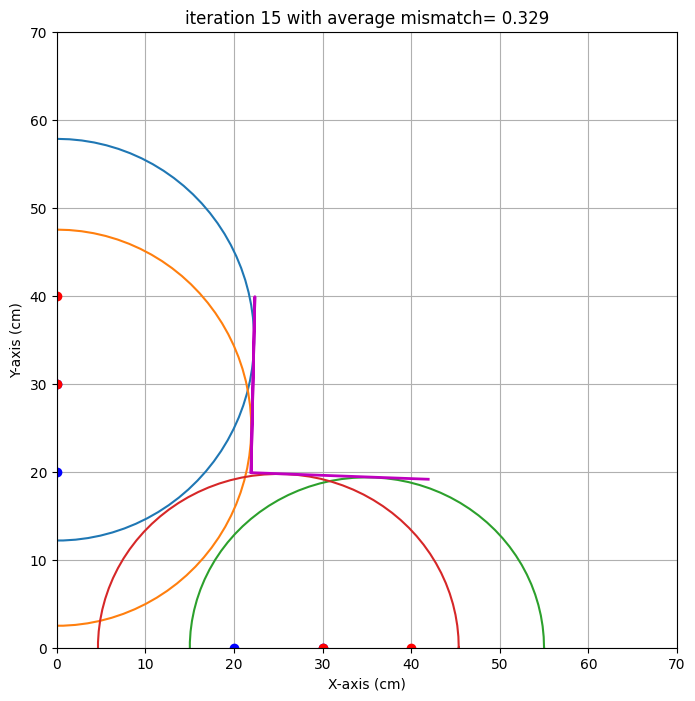

end iteration 15 with average mismatch= 0.329
end iteration 16 with average mismatch= 0.312
end iteration 17 with average mismatch= 0.312


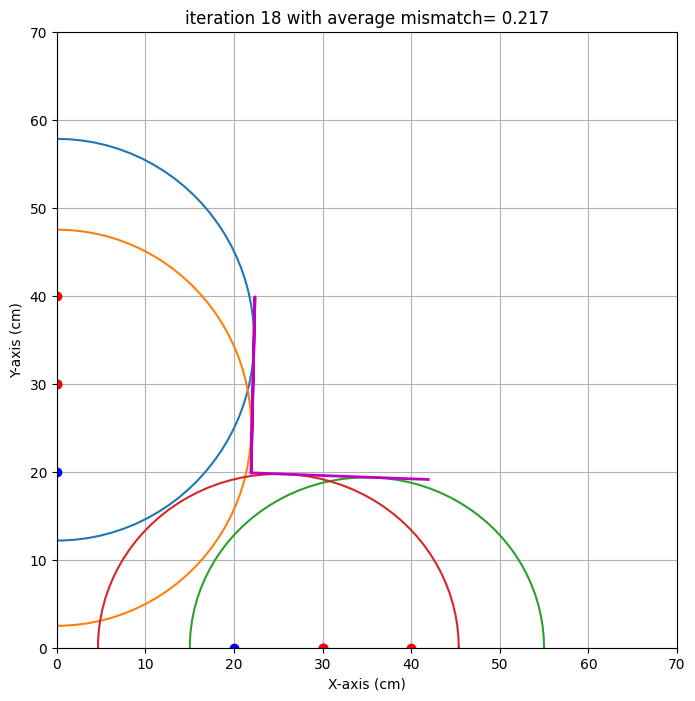

end iteration 18 with average mismatch= 0.217
end iteration 19 with average mismatch= 0.217
end iteration 20 with average mismatch= 0.217
end iteration 21 with average mismatch= 0.217
end iteration 22 with average mismatch= 0.217
end iteration 23 with average mismatch= 0.217
end iteration 24 with average mismatch= 0.217
end iteration 25 with average mismatch= 0.217
end iteration 26 with average mismatch= 0.217
end iteration 27 with average mismatch= 0.217
end iteration 28 with average mismatch= 0.217
end iteration 29 with average mismatch= 0.217
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.217
###############################################################################
end of iteration  30
Best alpha=  -2.15 with uncertainty=   0.02
Best beta =   1.24 with uncertainty=   1.21
Best x0   =  21.92 with uncertainty=   0.32
Best y0   

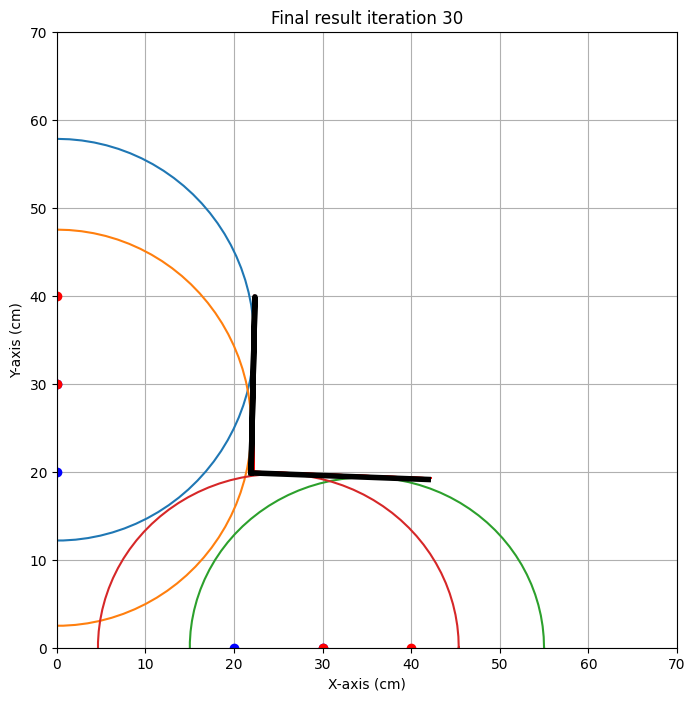

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,45.65],
    [0,30,0,20,45.02],
    [40,0,30,0,40],
    [30,0,20,0,40.74],  
    ])
# [10,0,0,10,]  meting buiten beschouwing gelaten omdat hier de hoek wordt gemeten.
# [10,0,20,0,43.2], 
# 
resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.9 cm met een standaardafwijking van 0.3 cm 
y0: 19.9 cm met een standaardafwijking van 0.2 cm 
alpha: -2.1 graden met een standaardafwijking van 0.0 graad 
beta: 1.2 graden met een standaardafwijking van 1.2 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Siemen Spek]
<img src="eerste_algoritme_siemen.jpeg" width="400">

#### algoritme [Batu Sönmez]
<img src="eerste_algoritme_batu.jpeg" width="400">

#### algoritme [Tom Jongbloed]
<img src="eerste_algoritme_tom.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':40,  
           'y0': 45,
           'alpha' : 25,
           'beta' : 30,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Siemen Spek' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # [0,30,0,35, ongeldig],
    # [0,45,0,50,ongeldig],
    [60,0,65,0, 93],
    [50,0,60,0, 88],
    #[30,0,35,0,ongeldig],
    [0,45,0,50,93],
    [0,50,0,55,90],
    # siemen
    ]),
       'Tom Jongbloed' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
      [65,0,55,0,87],
      [55,0,45,0,88.65],
      [0,75,0,65,102.3],
      [0,65,0,55,97],
    # tom
    ]),
       'Batu Sönmez' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #zelf aanvullen
    ])
      }

## Opdracht 7: Evaluatie.

Siemen Spek
Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  60   0  65   0  93
1  50   0  60   0  88
2   0  45   0  50  93
3   0  50   0  55  90


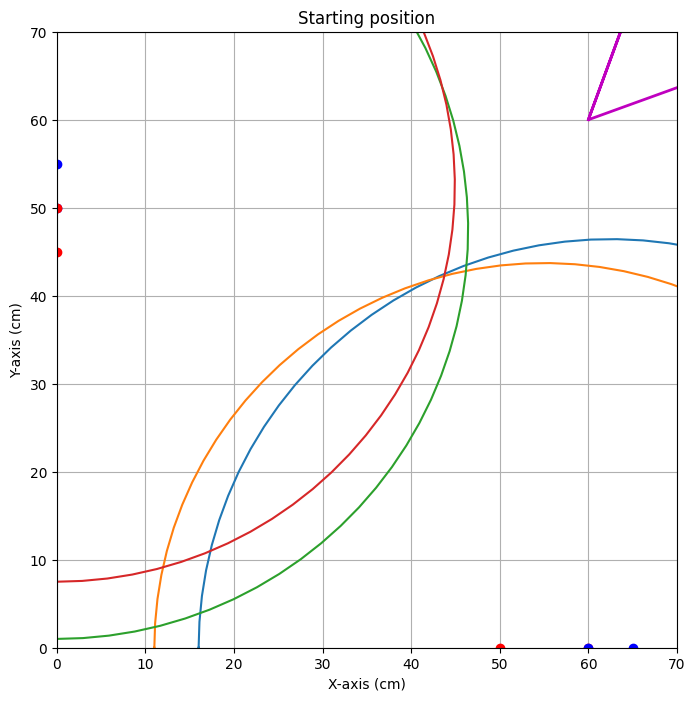


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=36.254


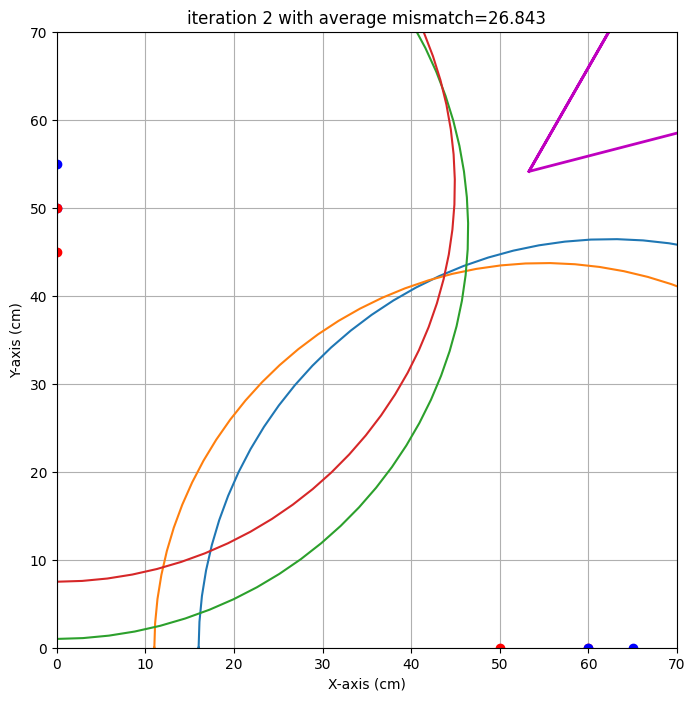

end iteration 2 with average mismatch=26.843


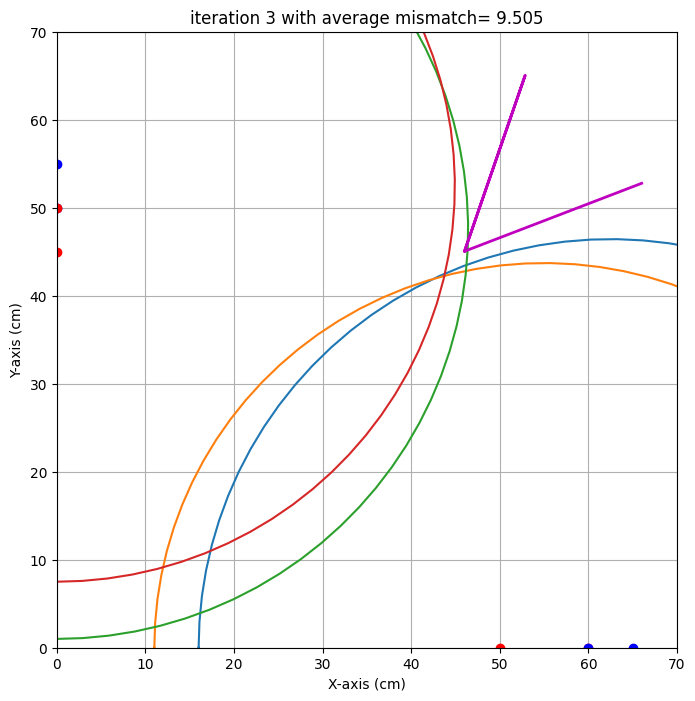

end iteration 3 with average mismatch= 9.505


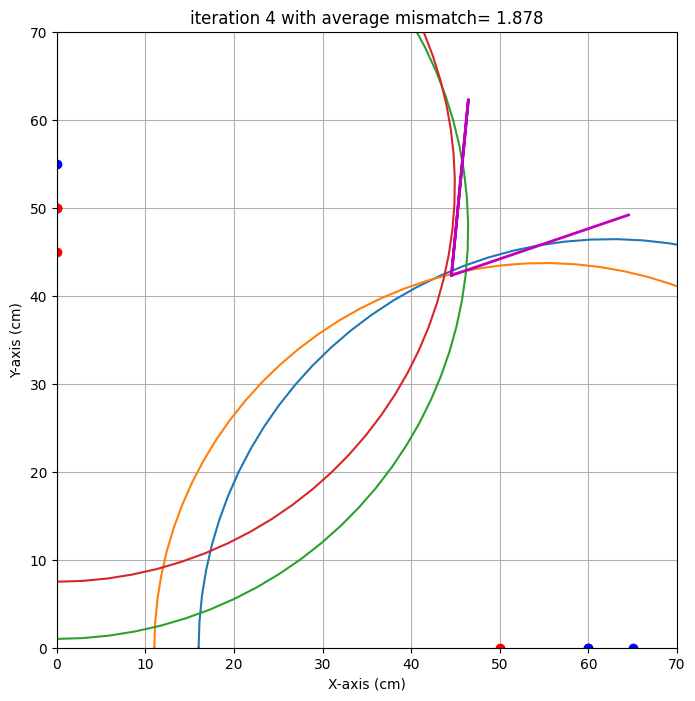

end iteration 4 with average mismatch= 1.878


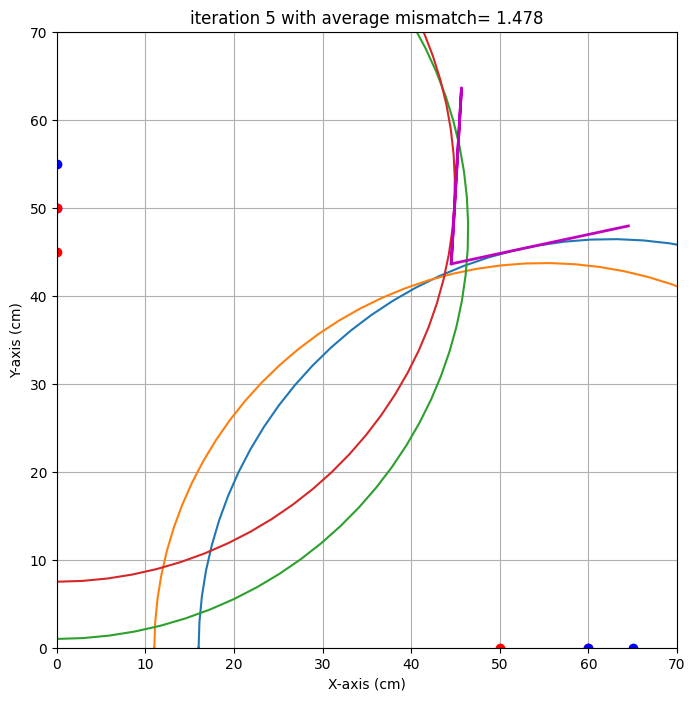

end iteration 5 with average mismatch= 1.478
end iteration 6 with average mismatch= 1.463


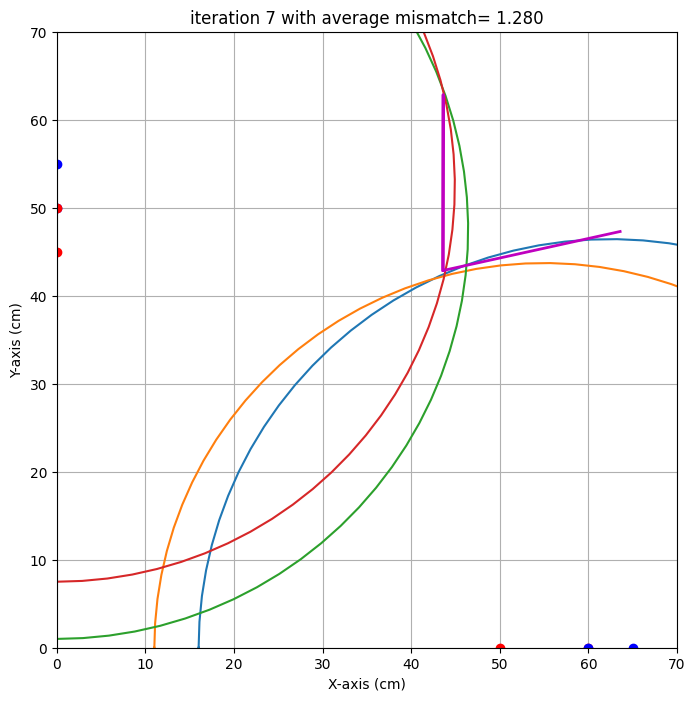

end iteration 7 with average mismatch= 1.280


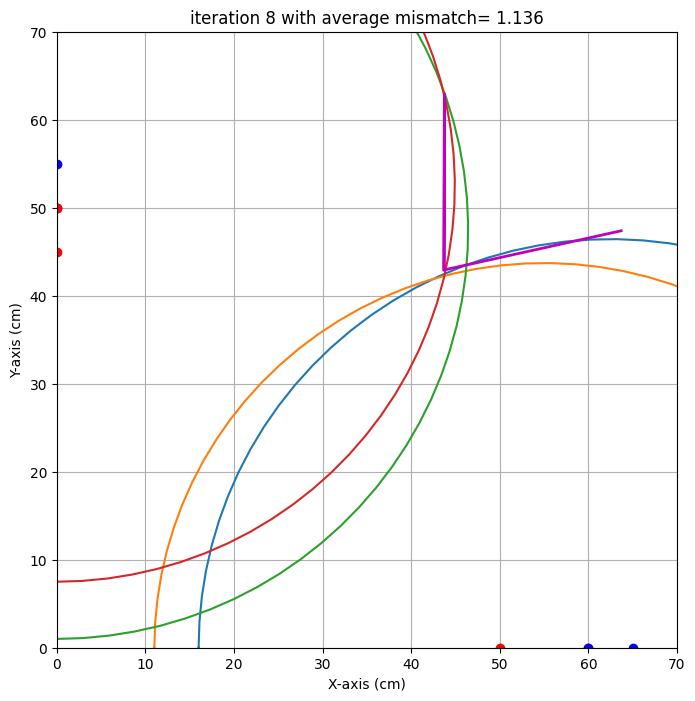

end iteration 8 with average mismatch= 1.136
end iteration 9 with average mismatch= 1.060
end iteration 10 with average mismatch= 1.059
end iteration 11 with average mismatch= 0.986
end iteration 12 with average mismatch= 0.965
end iteration 13 with average mismatch= 0.922
end iteration 14 with average mismatch= 0.883
end iteration 15 with average mismatch= 0.883
end iteration 16 with average mismatch= 0.883
end iteration 17 with average mismatch= 0.883
end iteration 18 with average mismatch= 0.883
end iteration 19 with average mismatch= 0.883
end iteration 20 with average mismatch= 0.883
end iteration 21 with average mismatch= 0.883
end iteration 22 with average mismatch= 0.883
end iteration 23 with average mismatch= 0.883
end iteration 24 with average mismatch= 0.883
end iteration 25 with average mismatch= 0.883
end iteration 26 with average mismatch= 0.883
end iteration 27 with average mismatch= 0.883
end iteration 28 with average mismatch= 0.883
end iteration 29 with average mismat

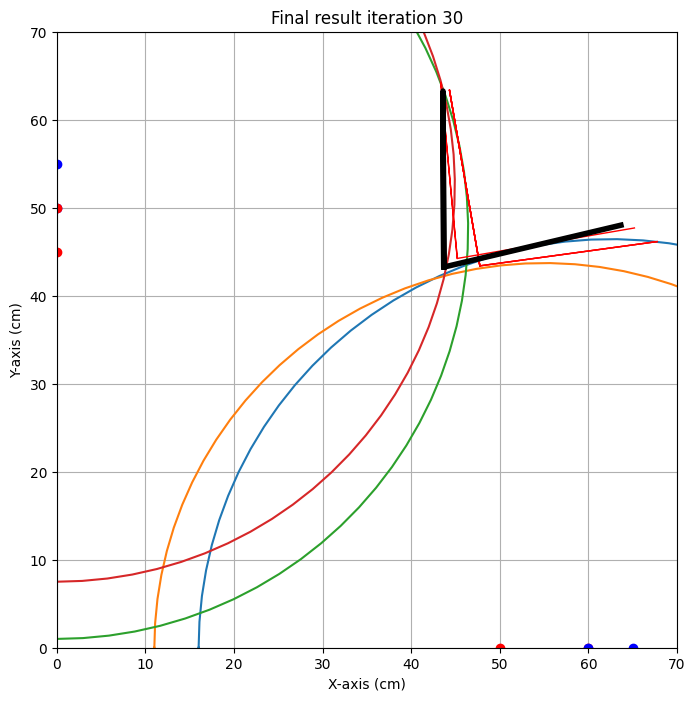

{'alpha': np.float64(13.389568899688829), 'alpha_eps': np.float64(5.543425320382772), 'beta': np.float64(-0.24622124221507327), 'beta_eps': np.float64(9.49949727219232), 'x0': np.float64(43.67619070266667), 'x0_eps': np.float64(4.075411048402231), 'y0': np.float64(43.2529923178887), 'y0_eps': np.float64(0.9847508830343088)}
Tom Jongbloed
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0  65   0  55   0   87.00
1  55   0  45   0   88.65
2   0  75   0  65  102.30
3   0  65   0  55   97.00


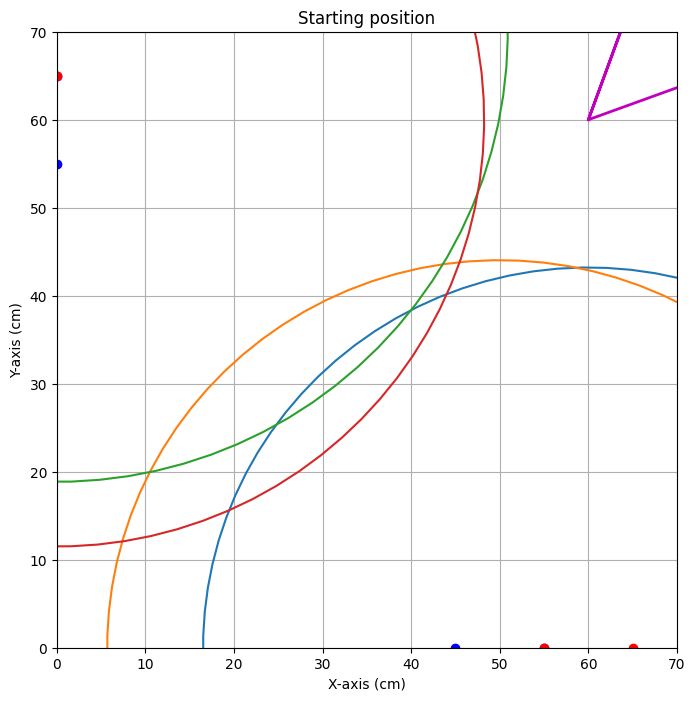


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=32.468


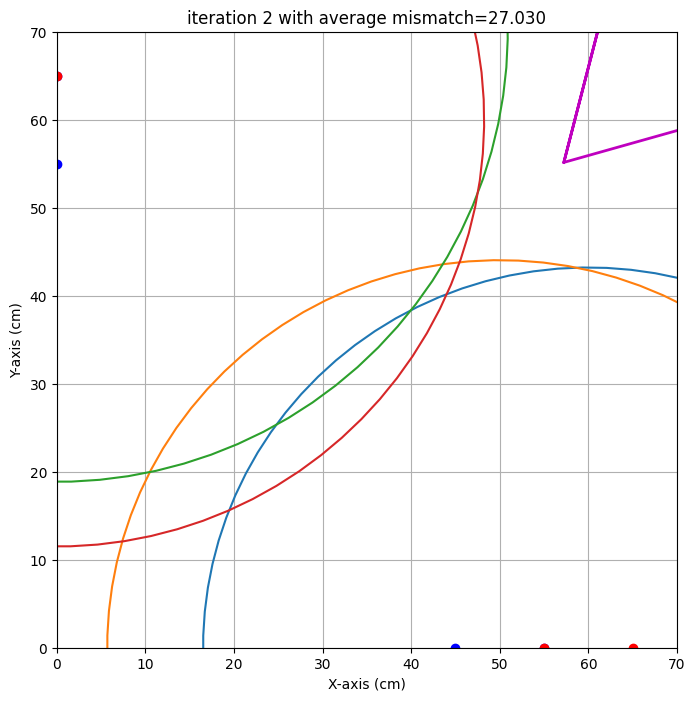

end iteration 2 with average mismatch=27.030


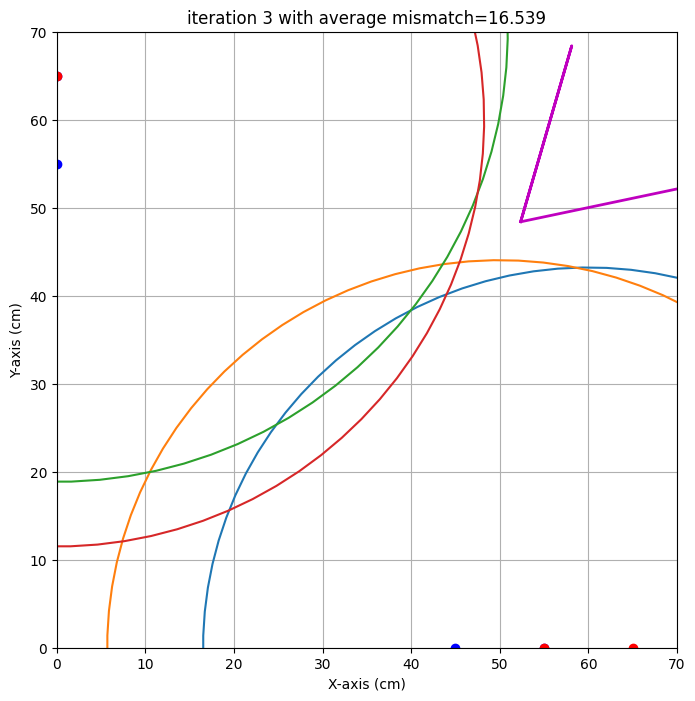

end iteration 3 with average mismatch=16.539


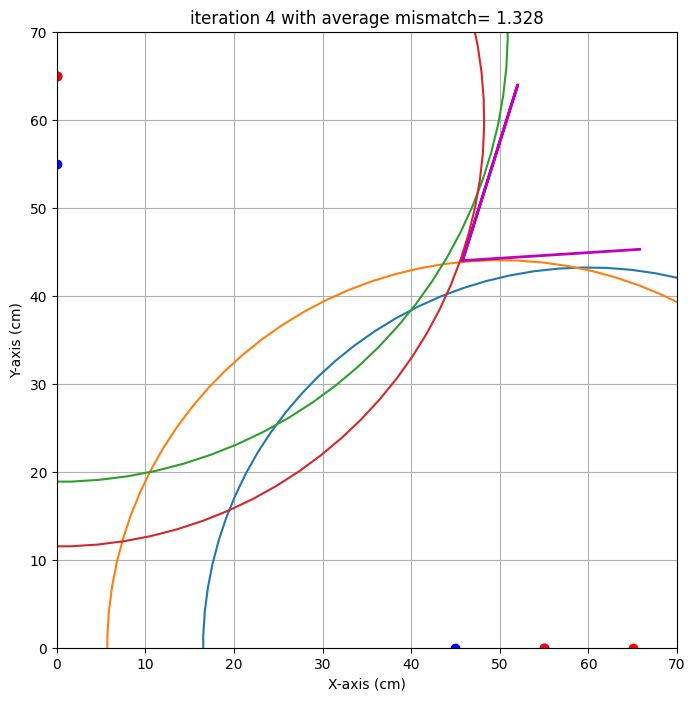

end iteration 4 with average mismatch= 1.328


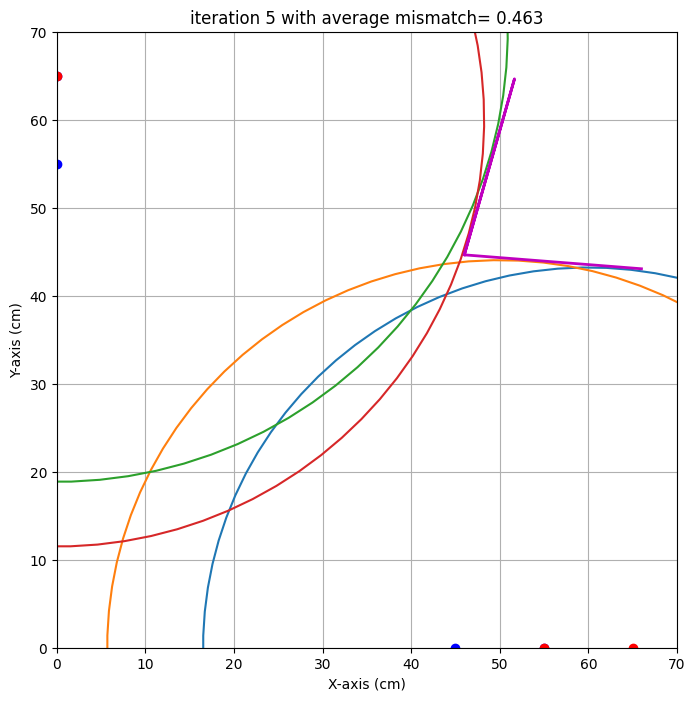

end iteration 5 with average mismatch= 0.463


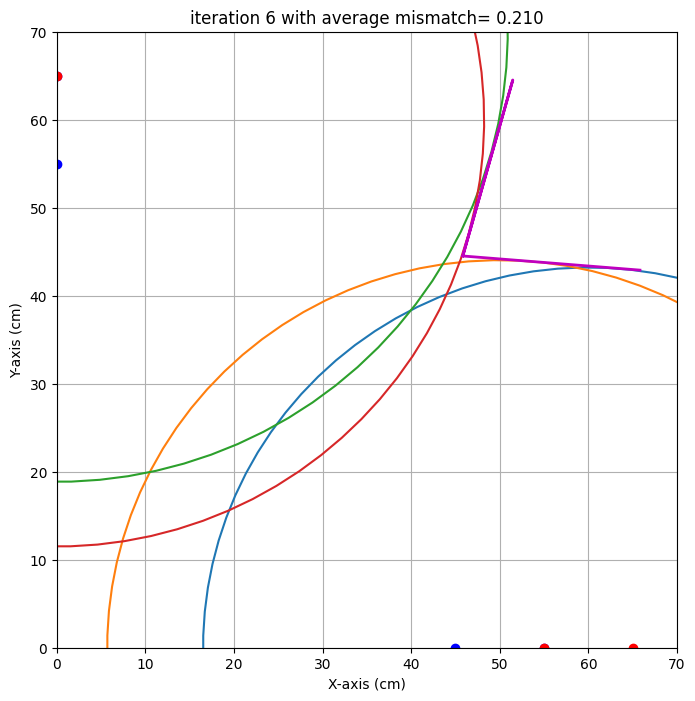

end iteration 6 with average mismatch= 0.210
end iteration 7 with average mismatch= 0.190
end iteration 8 with average mismatch= 0.189
end iteration 9 with average mismatch= 0.188
end iteration 10 with average mismatch= 0.188
end iteration 11 with average mismatch= 0.188
end iteration 12 with average mismatch= 0.188
end iteration 13 with average mismatch= 0.188
end iteration 14 with average mismatch= 0.188
end iteration 15 with average mismatch= 0.188
end iteration 16 with average mismatch= 0.188
end iteration 17 with average mismatch= 0.188
end iteration 18 with average mismatch= 0.188
end iteration 19 with average mismatch= 0.188
end iteration 20 with average mismatch= 0.188
end iteration 21 with average mismatch= 0.188
end iteration 22 with average mismatch= 0.188
end iteration 23 with average mismatch= 0.188
end iteration 24 with average mismatch= 0.188
end iteration 25 with average mismatch= 0.188
end iteration 26 with average mismatch= 0.188
end iteration 27 with average mismatch

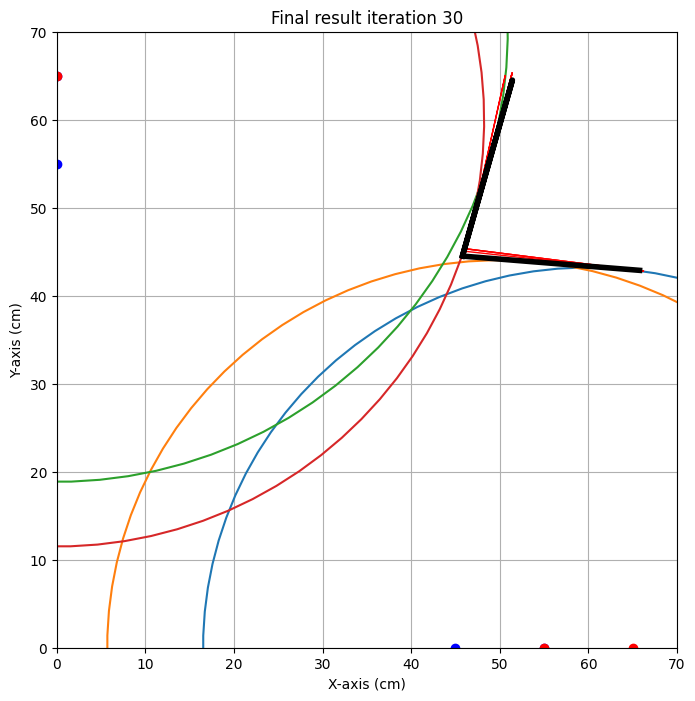

{'alpha': np.float64(-4.624628364622505), 'alpha_eps': np.float64(2.6004431146077174), 'beta': np.float64(15.756246640988813), 'beta_eps': np.float64(3.297168161527491), 'x0': np.float64(45.78282179293591), 'x0_eps': np.float64(0.4283165116863543), 'y0': np.float64(44.502351294005756), 'y0_eps': np.float64(0.8233829686575973)}
Batu Sönmez
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


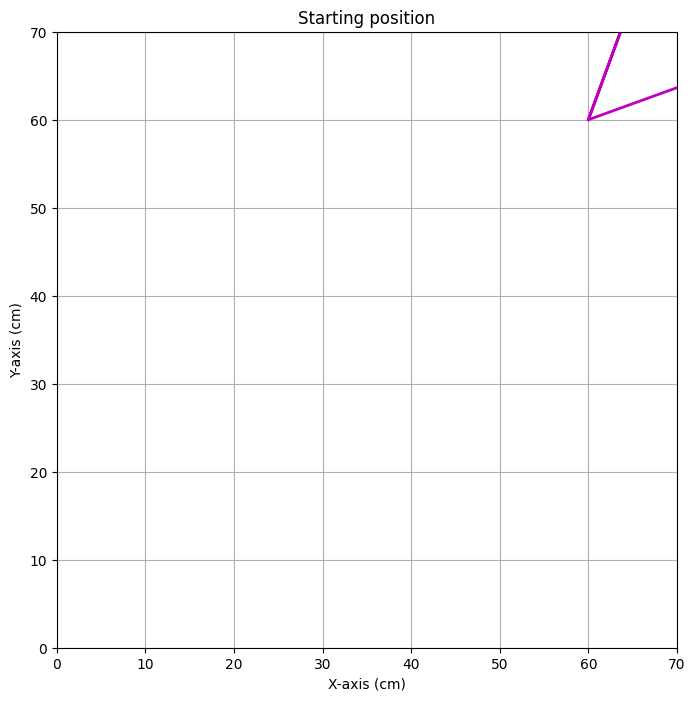


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan


c:\Users\sieme\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\sieme\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:146: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with average mismatch=   nan
end iteration 22 with average mismatch=   nan
end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatch=   nan
end iteration 29 with average mismatch=   nan
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

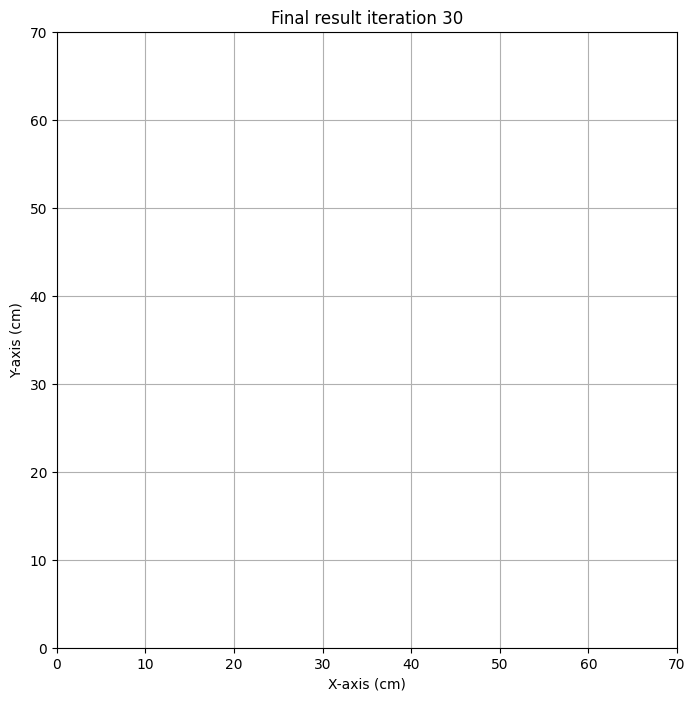

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Siemen Spek 
x0 target is : 40.0. Gevonden waarde: 43.7 cm met een standaardafwijking van 4.1 cm 
y0 target is : 45.0. Gevonden waarde: 43.3 cm met een standaardafwijking van 1.0 cm 
alpha target is : 25.0. Gevonden waarde: 13.4 graden met een standaardafwijking van 5.5 graad 
beta target is : 30.0. Gevonden waarde: -0.2 graden met een standaardafwijking van 9.5 graad 

Tom Jongbloed 
x0 target is : 40.0. Gevonden waarde: 45.8 cm met een standaardafwijking van 0.4 cm 
y0 target is : 45.0. Gevonden waarde: 44.5 cm met een standaardafwijking van 0.8 cm 
alpha target is : 25.0. Gevonden waarde: -4.6 graden met een standaardafwijking van 2.6 graad 
beta target is : 30.0. Gevonden waarde: 15.8 graden met een standaardafwijking van 3.3 graad 

Batu Sönmez 
x0 target is : 40.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 45.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 25.0. Gevonden waarde: nan graden met een standaardaf

## Opdracht 8: Iteratie1+.14.45.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme_einde.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  68.18
1   0  75   0  60  70.00
2   0  65   0  55  66.40
3   0  65   0  50  65.12
4  55   0  45   0  68.10
5  55   0  40   0  69.66


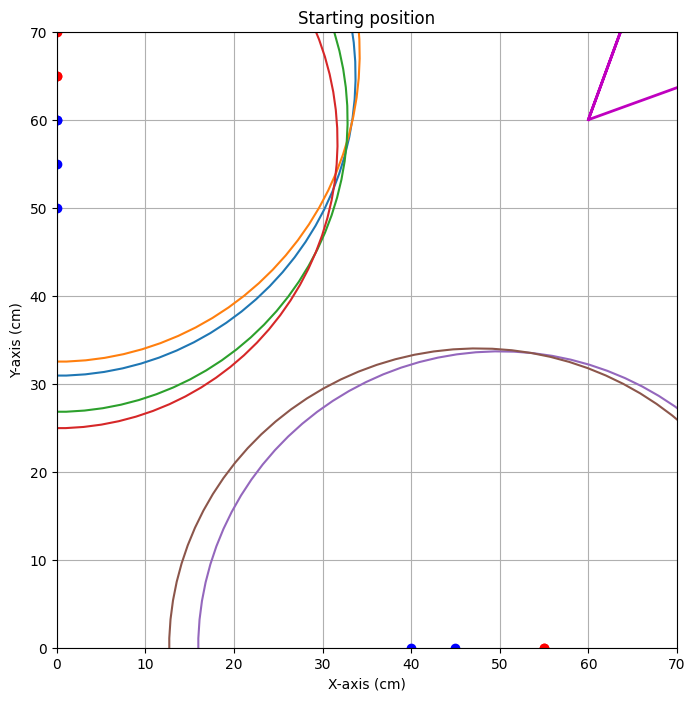


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.378


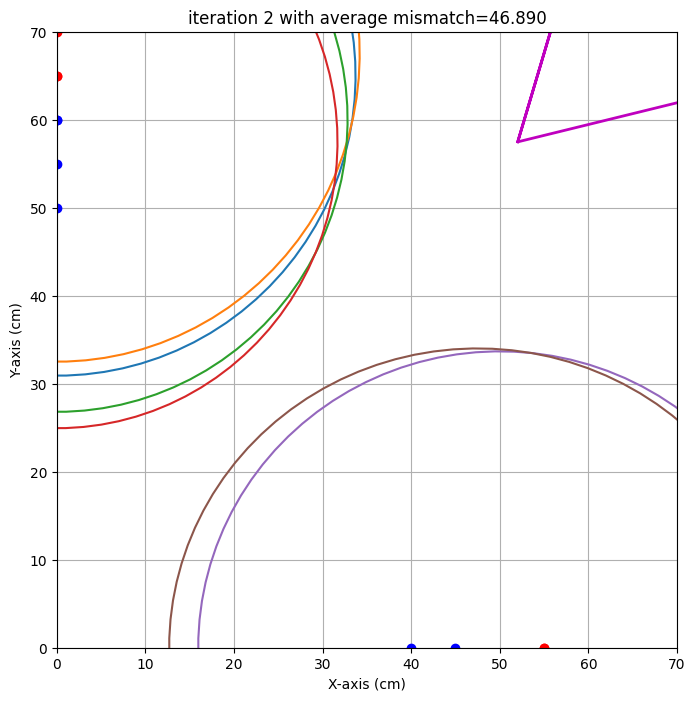

end iteration 2 with average mismatch=46.890


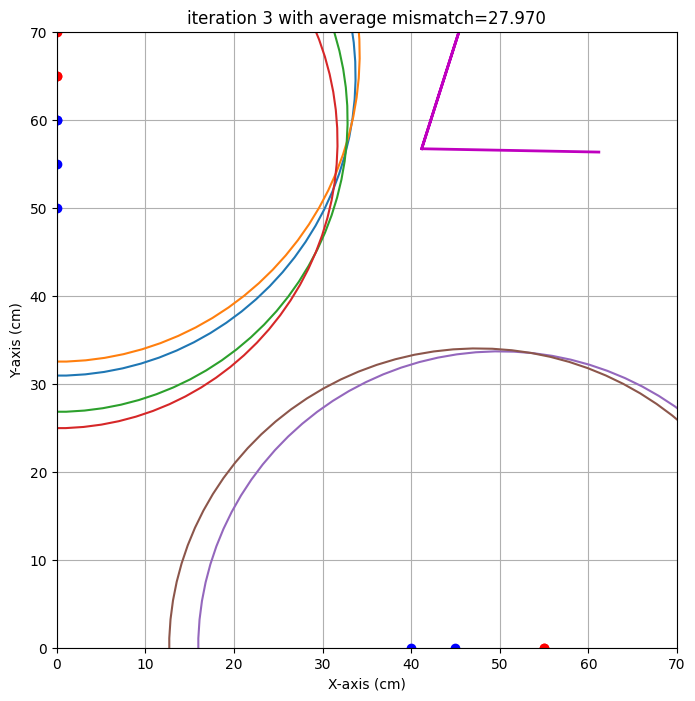

end iteration 3 with average mismatch=27.970


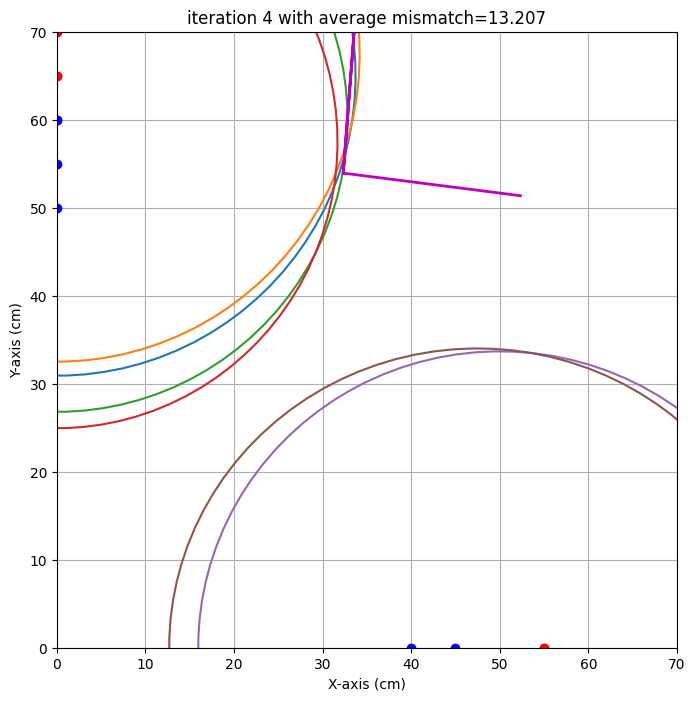

end iteration 4 with average mismatch=13.207


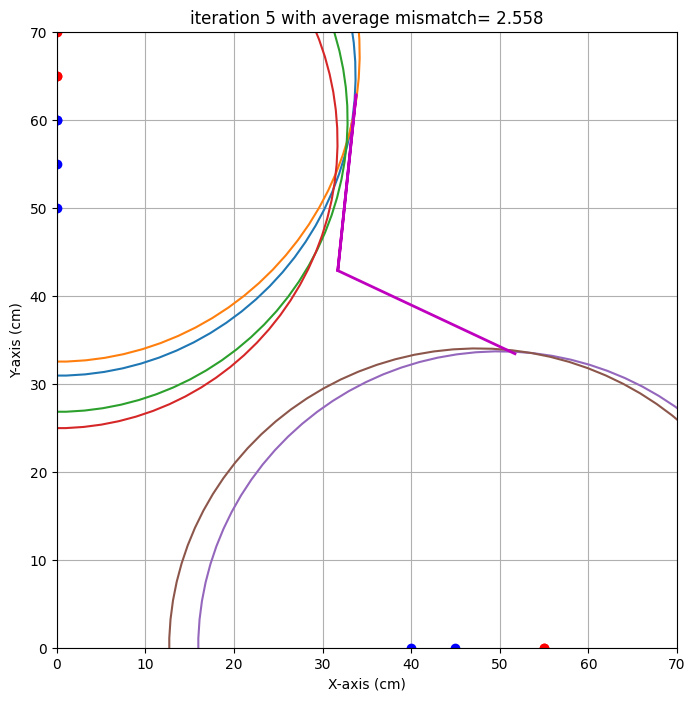

end iteration 5 with average mismatch= 2.558
end iteration 6 with average mismatch= 2.498


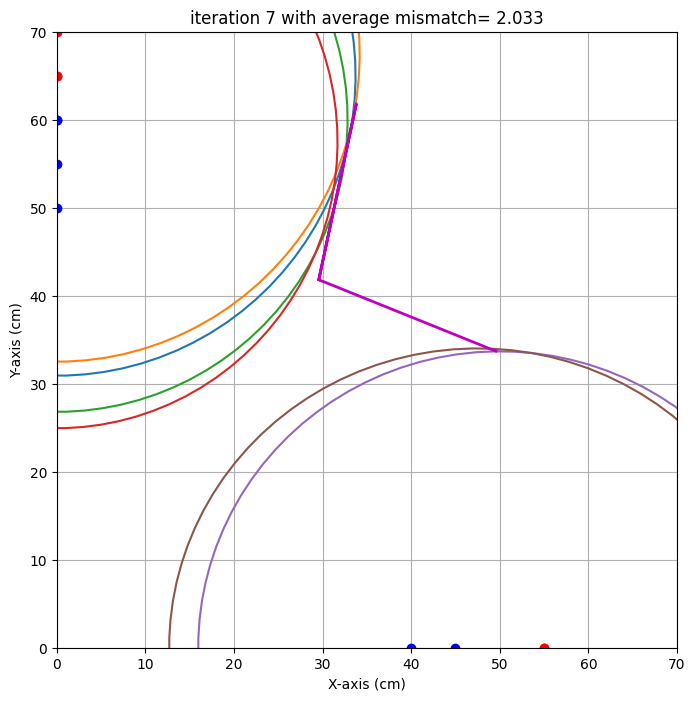

end iteration 7 with average mismatch= 2.033
end iteration 8 with average mismatch= 1.956
end iteration 9 with average mismatch= 1.956
end iteration 10 with average mismatch= 1.839
end iteration 11 with average mismatch= 1.839
end iteration 12 with average mismatch= 1.839
end iteration 13 with average mismatch= 1.839
end iteration 14 with average mismatch= 1.839
end iteration 15 with average mismatch= 1.839
end iteration 16 with average mismatch= 1.837
end iteration 17 with average mismatch= 1.827
end iteration 18 with average mismatch= 1.823
end iteration 19 with average mismatch= 1.822
end iteration 20 with average mismatch= 1.790
end iteration 21 with average mismatch= 1.742
end iteration 22 with average mismatch= 1.729
end iteration 23 with average mismatch= 1.726
end iteration 24 with average mismatch= 1.726
end iteration 25 with average mismatch= 1.726
end iteration 26 with average mismatch= 1.721
end iteration 27 with average mismatch= 1.688
end iteration 28 with average mismatc

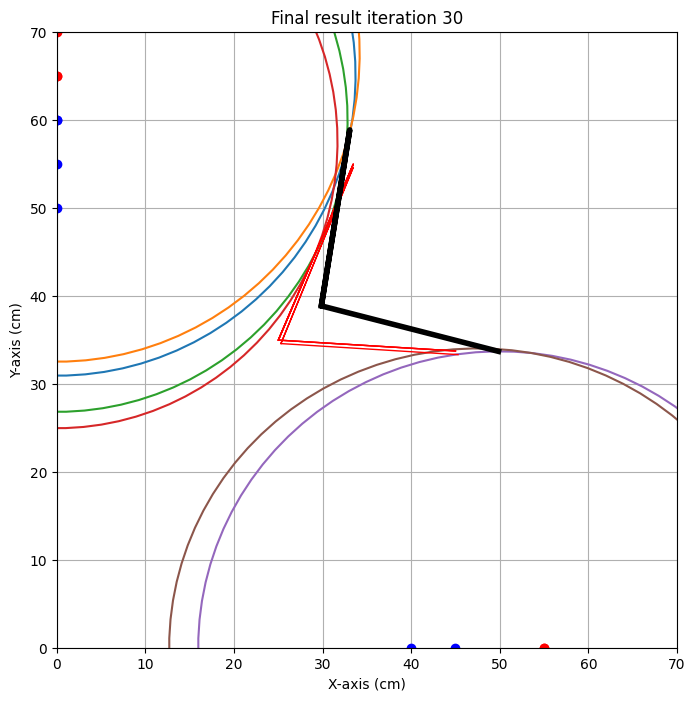

{'alpha': np.float64(-14.487017422922037), 'alpha_eps': np.float64(10.954622595233703), 'beta': np.float64(9.113779032888335), 'beta_eps': np.float64(13.829720812569189), 'x0': np.float64(29.854325522889997), 'x0_eps': np.float64(4.855189070917373), 'y0': np.float64(38.84532388894357), 'y0_eps': np.float64(4.284411480144584)}
locatie 1 
x0 target is : 27.0. Gevonden waarde: 29.9 cm met een standaardafwijking van 4.9 cm 
y0 target is : 35.0. Gevonden waarde: 38.8 cm met een standaardafwijking van 4.3 cm 
alpha target is : -26.0. Gevonden waarde: -14.5 graden met een standaardafwijking van 11.0 graad 
beta target is : 20.0. Gevonden waarde: 9.1 graden met een standaardafwijking van 13.8 graad 



In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27,
                    'y0': 35,
                    'alpha' : -26,
                    'beta' : 20,                  
           'locatie 2':{'x0':34,
                    'y0':34,
                    'alpha' :34, 
                    'beta' :34, 
            }}}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,68.18],
    [0,75,0,60,70],
    [0,65,0,55,66.4],
    [0,65,0,50,65.12],
    # [60,0,50,0,79],
    # [65,0,50,0,ongeldig],
    [55,0,45,0,68.1],
    [55,0,40,0,69.66],
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  55   0  45  53.0
1   0  50   0  40  48.5
2   0  50   0  35  51.0
3  45   0  35   0  45.0
4  50   0  35   0  44.9
5  40   0  30   0  47.0
6  40   0  25   0  49.2


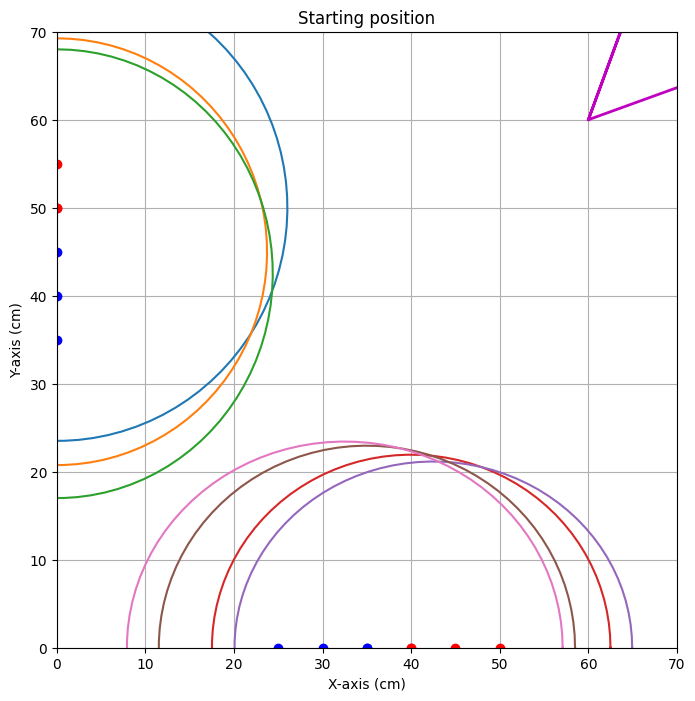


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.182


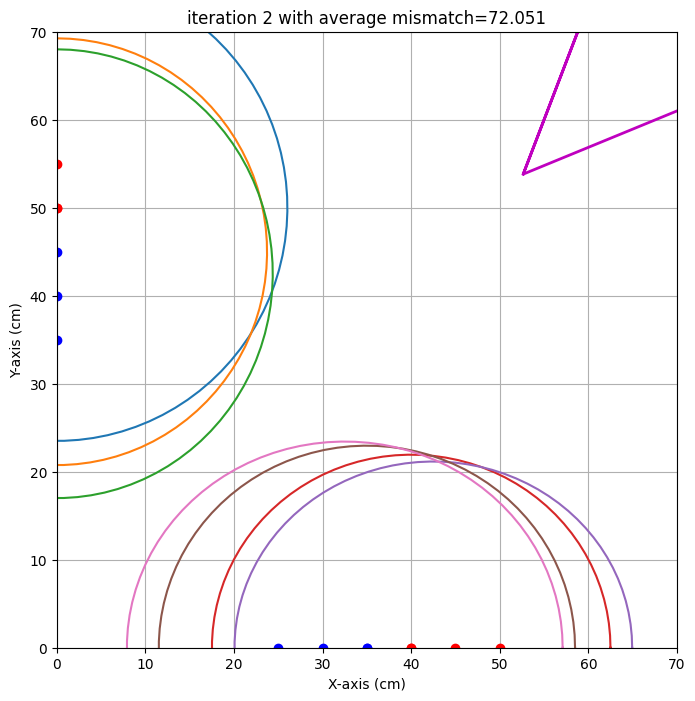

end iteration 2 with average mismatch=72.051


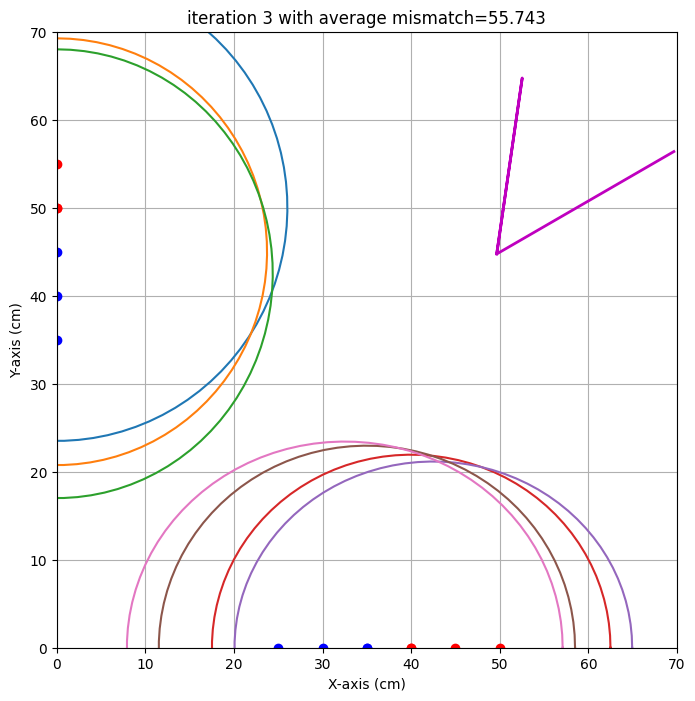

end iteration 3 with average mismatch=55.743


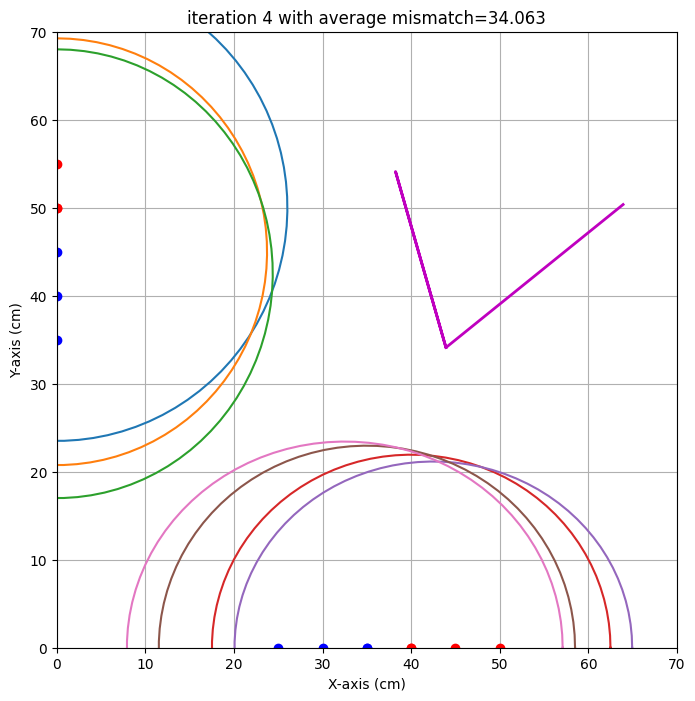

end iteration 4 with average mismatch=34.063


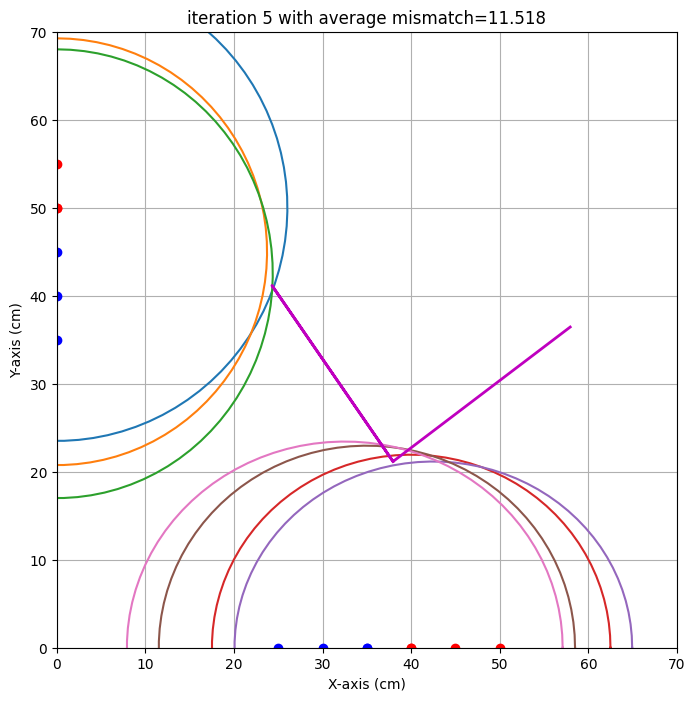

end iteration 5 with average mismatch=11.518


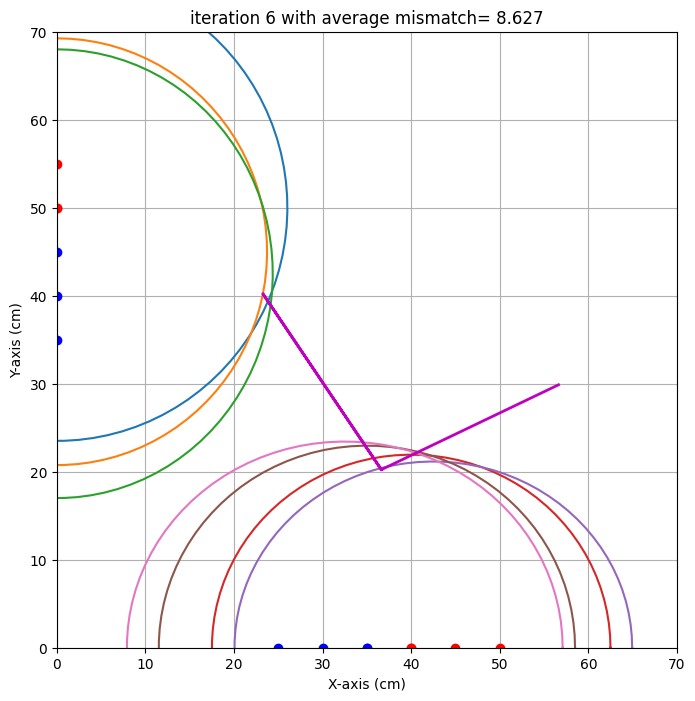

end iteration 6 with average mismatch= 8.627
end iteration 7 with average mismatch= 8.454


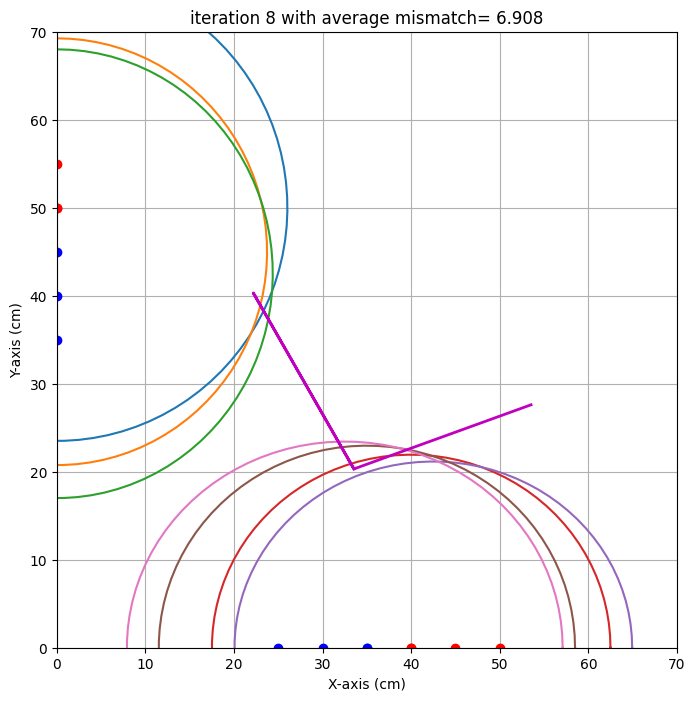

end iteration 8 with average mismatch= 6.908


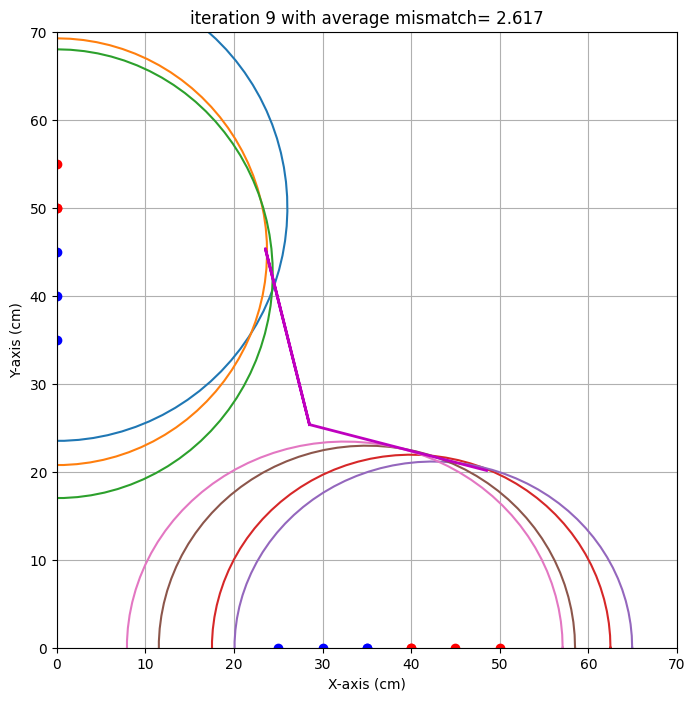

end iteration 9 with average mismatch= 2.617


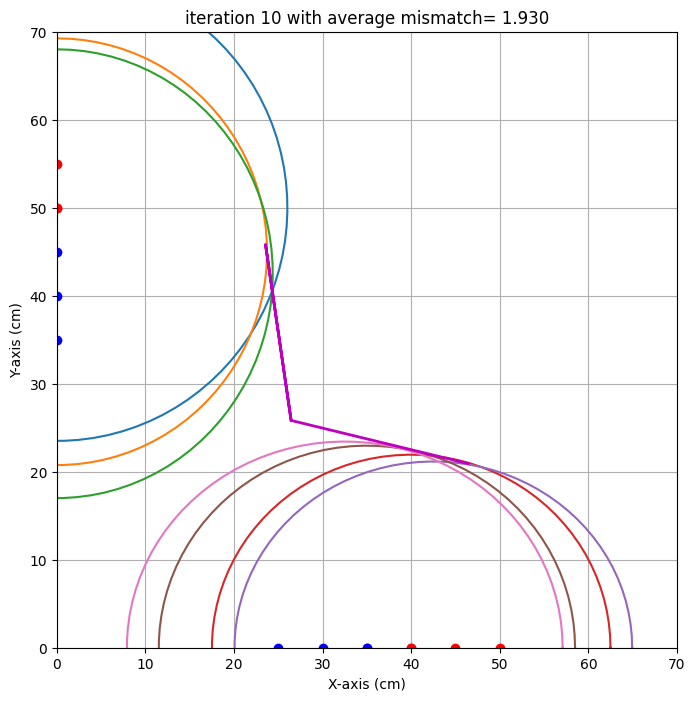

end iteration 10 with average mismatch= 1.930
end iteration 11 with average mismatch= 1.930
end iteration 12 with average mismatch= 1.930
end iteration 13 with average mismatch= 1.930
end iteration 14 with average mismatch= 1.904
end iteration 15 with average mismatch= 1.904
end iteration 16 with average mismatch= 1.904
end iteration 17 with average mismatch= 1.853
end iteration 18 with average mismatch= 1.788
end iteration 19 with average mismatch= 1.788


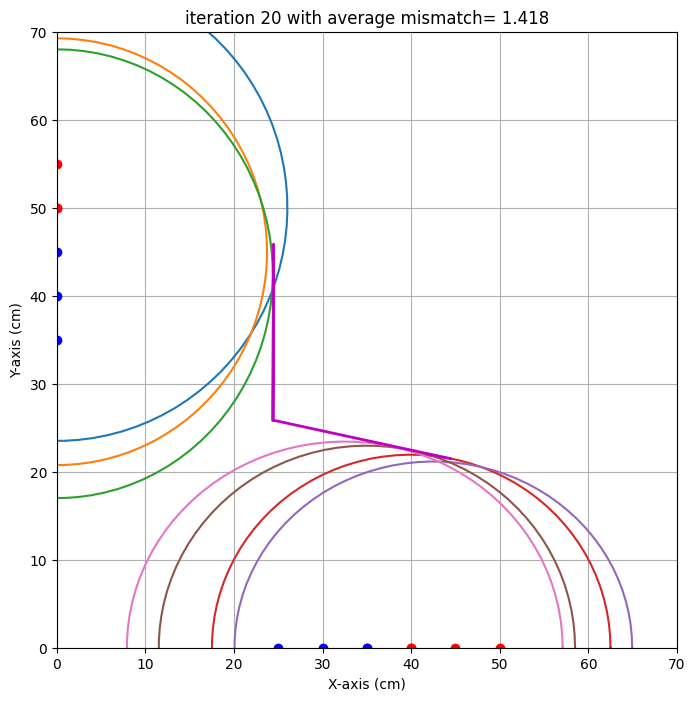

end iteration 20 with average mismatch= 1.418
end iteration 21 with average mismatch= 1.415
end iteration 22 with average mismatch= 1.379
end iteration 23 with average mismatch= 1.374
end iteration 24 with average mismatch= 1.373
end iteration 25 with average mismatch= 1.373
end iteration 26 with average mismatch= 1.373
end iteration 27 with average mismatch= 1.373
end iteration 28 with average mismatch= 1.373
end iteration 29 with average mismatch= 1.373
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.373
###############################################################################
end of iteration  30
Best alpha= -12.58 with uncertainty=   8.52
Best beta =  -0.22 with uncertainty=  11.70
Best x0   =  24.44 with uncertainty=   3.20
Best y0   =  25.90 with uncertainty=   1.87
###############################################################################


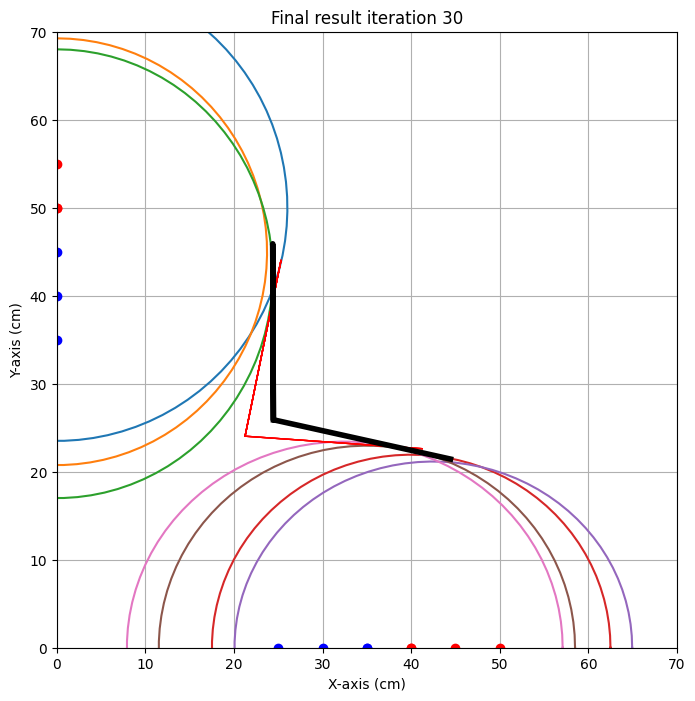

{'alpha': np.float64(-12.584560041931983), 'alpha_eps': np.float64(8.522066956344485), 'beta': np.float64(-0.22304992032053492), 'beta_eps': np.float64(11.70021786220132), 'x0': np.float64(24.44204525879797), 'x0_eps': np.float64(3.1982001951508003), 'y0': np.float64(25.903116264531874), 'y0_eps': np.float64(1.8660462126591533)}
test locatie 
x0 target is : 25.6. Gevonden waarde: 24.4 cm met een standaardafwijking van 3.2 cm 
y0 target is : 26.2. Gevonden waarde: 25.9 cm met een standaardafwijking van 1.9 cm 
alpha target is : -15.0. Gevonden waarde: -12.6 graden met een standaardafwijking van 8.5 graad 
beta target is : -2.0. Gevonden waarde: -0.2 graden met een standaardafwijking van 11.7 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 25.6 ,
                    'y0': 26.2 ,
                    'alpha' : -15 ,
                    'beta' :  -2
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # [0,70,0,60,ongeldig],
                    # [0,55,0,45,56],
                    # [0,60,0,45,ongeldig],
                    # [0,50,0,40,51.2],
                    # [0,50,0,35,54],
                    # [60,0,50,0,ongeldig],
                    # [45,0,35,0,47],
                    # [50,0,35,0,47.5],
                    # [40,0,30,0,50],
                    # [40,0,25,0,52],
                    # tweede metingen:
                    # [0,70,0,60,ongeldig],
                    [0,55,0,45,53],
                    [0,50,0,40,48.5],
                    [0,50,0,35,51],
                    # [60,0,50,0,ongeldig],
                    [45,0,35,0,45],
                    [50,0,35,0,44.9],
                    [40,0,30,0,47],
                    [40,0,25,0,49.2],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

De blauwe ellips valt deze buiten onze waarden, omdat wij hierbij precies de rand meten.

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](eerste_algoritme_siemen.jpeg "Title")
evaluaties:
werkte niet goed, geeft heel andere hoeken dan gemeten. Vooral verschillende afstanden tussen bron en ontvanger toevoegen.

Figuur: ![Alt](iteratie_1.jpeg "Title")
evaluaties: komt in de buurt, nog steeds hoeken niet goed bepaald, dus nog meer metingen met kleine variatie in afstand tussen bron en ontvanger.

Figuur: ![Alt](algoritme_einde.jpeg "Title")

onze uiteindelijke meetopstelling:
Figuur: ![Alt](uiteindelijke_meetopstelling.jpeg "Title")

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  55   0  45  53.0
1   0  50   0  40  48.5
2   0  50   0  35  51.0
3  45   0  35   0  45.0
4  50   0  35   0  44.9
5  40   0  30   0  47.0
6  40   0  25   0  49.2


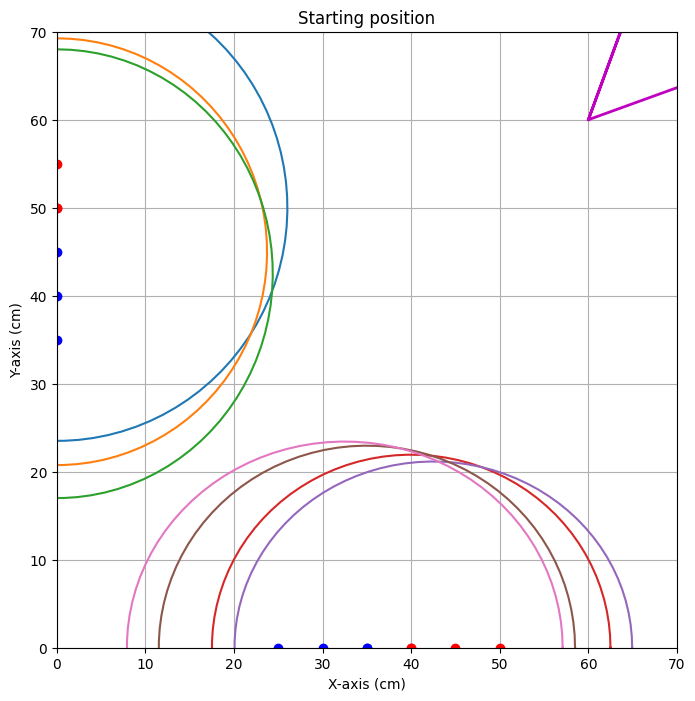


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.182


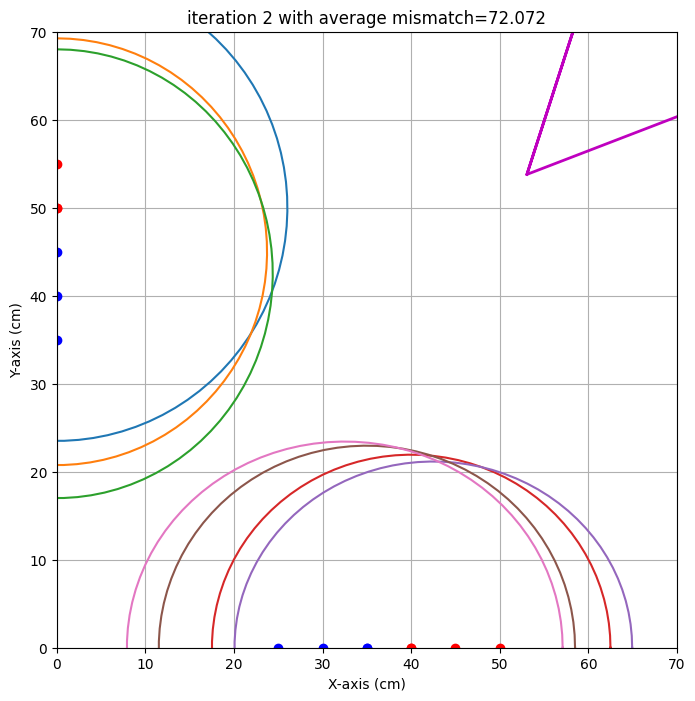

end iteration 2 with average mismatch=72.072


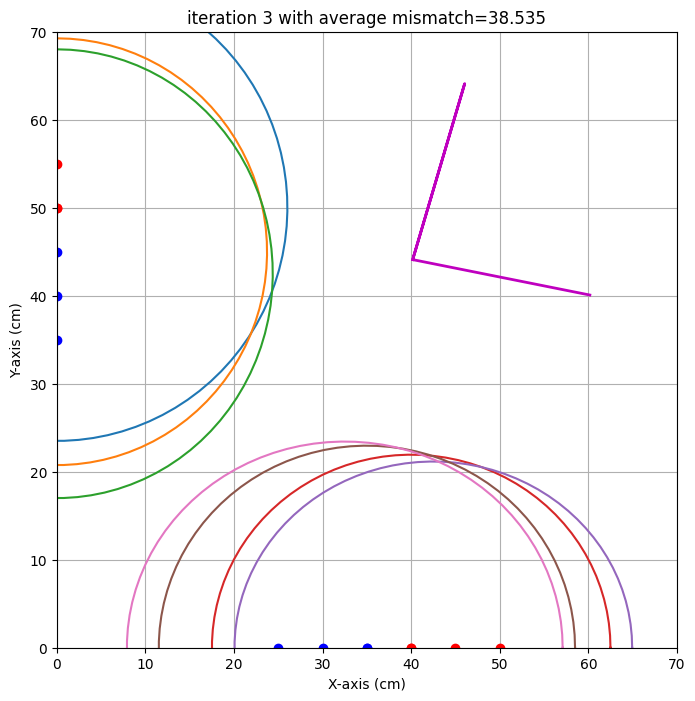

end iteration 3 with average mismatch=38.535


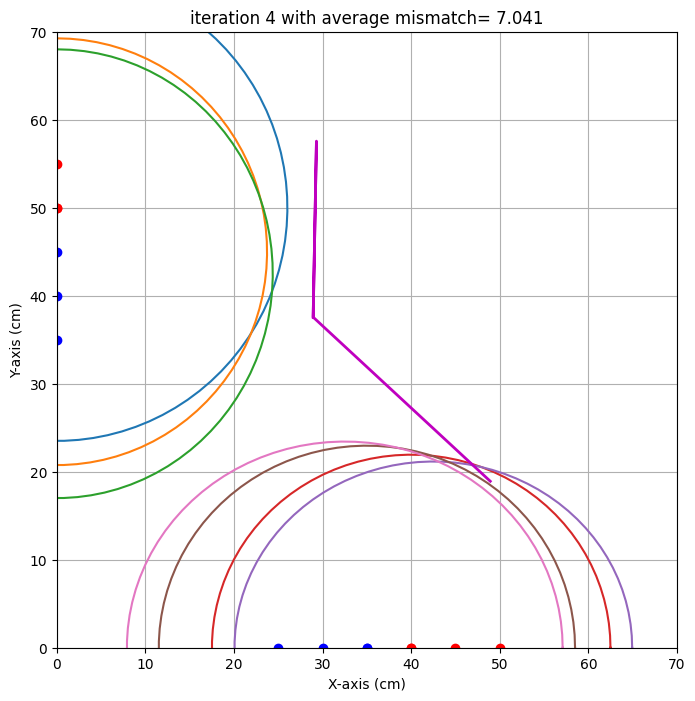

end iteration 4 with average mismatch= 7.041


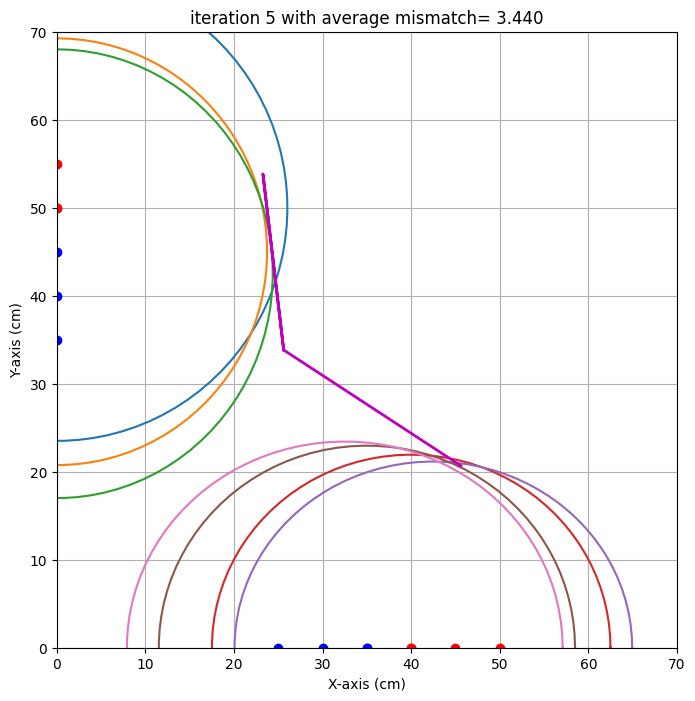

end iteration 5 with average mismatch= 3.440


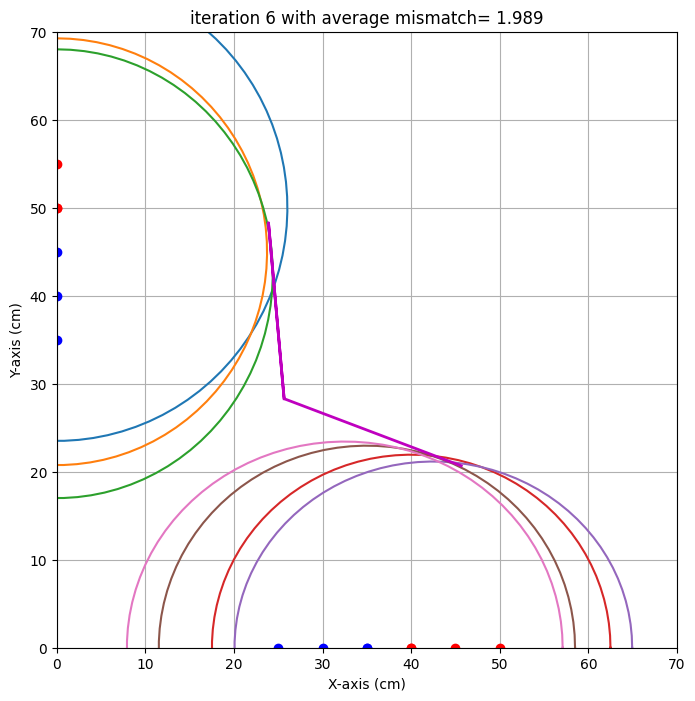

end iteration 6 with average mismatch= 1.989
end iteration 7 with average mismatch= 1.811
end iteration 8 with average mismatch= 1.664


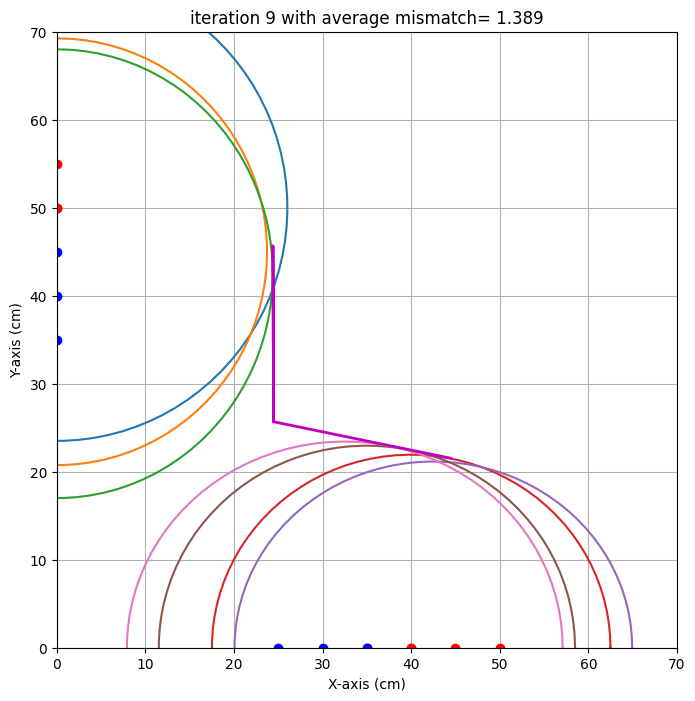

end iteration 9 with average mismatch= 1.389
end iteration 10 with average mismatch= 1.361
end iteration 11 with average mismatch= 1.361
end iteration 12 with average mismatch= 1.361
end iteration 13 with average mismatch= 1.361
end iteration 14 with average mismatch= 1.361
end iteration 15 with average mismatch= 1.361
end iteration 16 with average mismatch= 1.361
end iteration 17 with average mismatch= 1.361
end iteration 18 with average mismatch= 1.361
end iteration 19 with average mismatch= 1.361
end iteration 20 with average mismatch= 1.361
end iteration 21 with average mismatch= 1.361
end iteration 22 with average mismatch= 1.361
end iteration 23 with average mismatch= 1.361
end iteration 24 with average mismatch= 1.361
end iteration 25 with average mismatch= 1.361
end iteration 26 with average mismatch= 1.361
end iteration 27 with average mismatch= 1.361
end iteration 28 with average mismatch= 1.361
end iteration 29 with average mismatch= 1.361
Last iteration, also determine unce

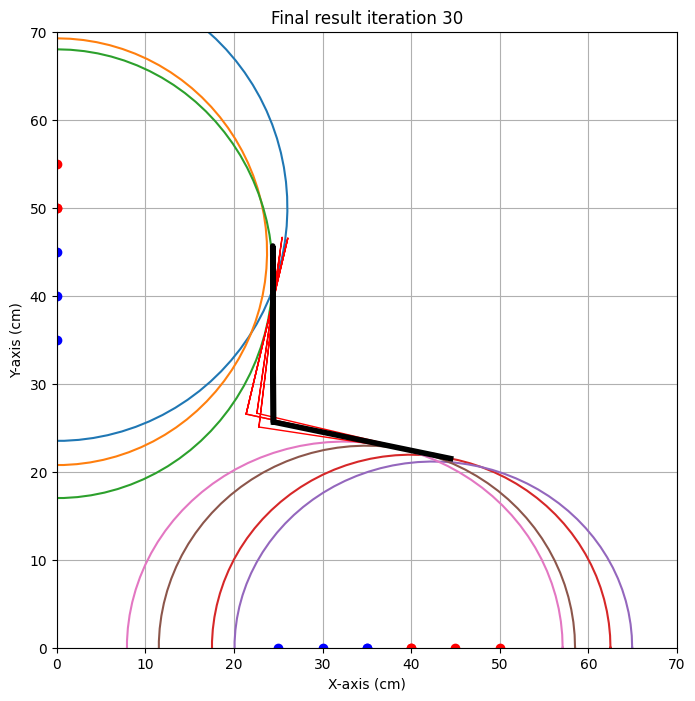

{'alpha': np.float64(-11.744510454419082), 'alpha_eps': np.float64(3.0918400929002487), 'beta': np.float64(-0.22984869243613887), 'beta_eps': np.float64(13.467004668807869), 'x0': np.float64(24.448476975104775), 'x0_eps': np.float64(3.0817159975989554), 'y0': np.float64(25.652363485809698), 'y0_eps': np.float64(0.9957831883176382)}
test locatie 
x0 target is : 25.6. Gevonden waarde: 24.4 cm met een standaardafwijking van 3.1 cm 
y0 target is : 26.2. Gevonden waarde: 25.7 cm met een standaardafwijking van 1.0 cm 
alpha target is : -15.0. Gevonden waarde: -11.7 graden met een standaardafwijking van 3.1 graad 
beta target is : -2.0. Gevonden waarde: -0.2 graden met een standaardafwijking van 13.5 graad 



In [13]:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0': 25.6 ,
                    'y0': 26.2 ,
                    'alpha' : -15 ,
                    'beta' :  -2
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # [0,70,0,60,ongeldig],
                    # [0,55,0,45,56],
                    # [0,60,0,45,ongeldig],
                    # [0,50,0,40,51.2],
                    # [0,50,0,35,54],
                    # [60,0,50,0,ongeldig],
                    # [45,0,35,0,47],
                    # [50,0,35,0,47.5],
                    # [40,0,30,0,50],
                    # [40,0,25,0,52],
                    # tweede metingen:
                    # [0,70,0,60,ongeldig],
                    [0,55,0,45,53],
                    [0,50,0,40,48.5],
                    [0,50,0,35,51],
                    # [60,0,50,0,ongeldig],
                    [45,0,35,0,45],
                    [50,0,35,0,44.9],
                    [40,0,30,0,47],
                    [40,0,25,0,49.2],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))